# GMM with Incomplete Data: Step-by-Step Experiment

Dựa trên bài báo: *Gaussian Mixture Model Clustering with Incomplete Data*.
Notebook này sẽ giải thích chi tiết từng bước toán học và đối chiếu trực tiếp với việc implement trong code.

## 1. Môi trường & Khởi tạo (Environment Setup)

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src')
from utils import generate_synthetic_data, mean_imputation
from gmm_missing import GMMMissing

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

## 2. Tạo dữ liệu giả lập (Data Generation)
Ta sẽ tạo ra dữ liệu 2D gồm 3 cụm (clusters), sau đó chủ động xóa ngẫu nhiên 30% dữ liệu (Missing Completely At Random - MCAR) để thử nghiệm cơ chế bù khuyết của thuật toán.

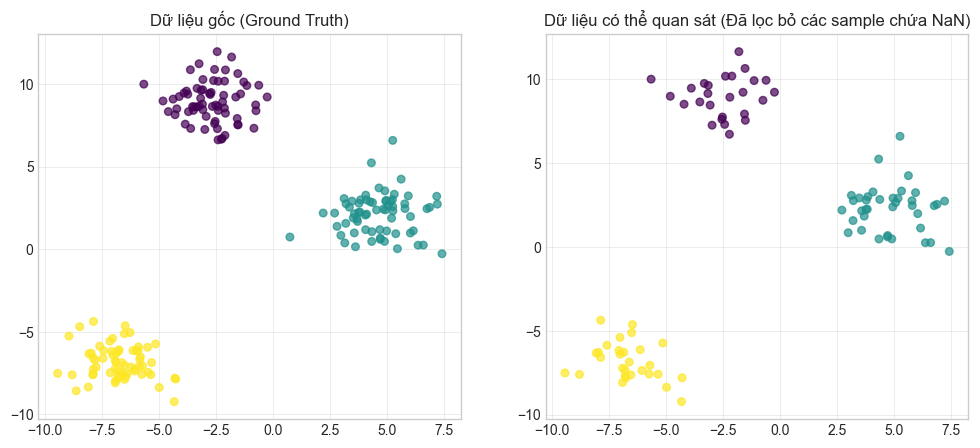

Tổng số mẫu: 200
Số lượng mẫu bị thiếu ít nhất 1 feature (NaN): 107


In [3]:
X_true, X_incomplete, y_true, mask_missing = generate_synthetic_data(
    n_samples=200, n_features=2, centers=3, cluster_std=1.2, missing_ratio=0.3, random_state=42
)

# Trực quan hóa dữ liệu gốc vs khi bị xóa
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_true[:, 0], X_true[:, 1], c=y_true, cmap='viridis', s=30, alpha=0.7)
plt.title("Dữ liệu gốc (Ground Truth)")

plt.subplot(1, 2, 2)
complete_rows = ~mask_missing.any(axis=1)
plt.scatter(X_incomplete[complete_rows, 0], X_incomplete[complete_rows, 1], 
            c=y_true[complete_rows], cmap='viridis', s=30, alpha=0.7)
plt.title("Dữ liệu có thể quan sát (Đã lọc bỏ các sample chứa NaN)")
plt.show()

print(f"Tổng số mẫu: {len(X_incomplete)}")
print(f"Số lượng mẫu bị thiếu ít nhất 1 feature (NaN): {np.sum(mask_missing.any(axis=1))}")

## 3. Khởi tạo (Initialization)
Thuật toán GMM thông thường không thể chạy nếu có chứa `NaN`. Do đó ở Bước 1 của Algorithm 1:
1. Thay thế tạm thời NaNs bằng giá trị trung bình cột (Mean Imputation).
2. Khởi tạo các tham số $\mu$ (kỳ vọng), $\Sigma$ (ma trận hiệp phương sai), $\alpha$ (trọng số cụm) bằng thuật toán K-Means.

In [4]:
# Nội suy thô bằng Mean
X_initial = mean_imputation(X_incomplete)

gmm = GMMMissing(n_components=3,max_iter=1, tol=1e-4, random_state=42)
gmm._initialize_parameters(X_initial)

print("Trung bình các cụm (mu) khởi tạo từ K-Means:\n", gmm.mu_)

Trung bình các cụm (mu) khởi tạo từ K-Means:
 [[-2.9542  4.7568]
 [ 4.6863  2.0197]
 [-4.6978 -6.8988]]


## 4. E-Step: Tính Posterior Probability (Kỳ vọng)
Tính xác suất hậu nghiệm $\gamma_{ji}$ (responsibility) biểu thị mẫu $x_j$ thuộc về cụm $i$ với xác suất bao nhiêu:

$$ \gamma_{ji} = \frac{\alpha_i p(x_j | \mu_i, \Sigma_i)}{\sum_{l=1}^k \alpha_l p(x_j | \mu_l, \Sigma_l)} $$

Bước này giúp thuật toán "cân đo" xem mỗi điểm dữ liệu đang ở gần Gaussian component nào nhất.

In [5]:
log_likelihood, gamma = gmm._e_step(X_initial)
print("Xác suất hậu nghiệm gamma (5 mẫu đầu tiên):\n", gamma[:5])

Xác suất hậu nghiệm gamma (5 mẫu đầu tiên):
 [[0.     1.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [0.0005 0.     0.9995]
 [0.0207 0.     0.9793]]


## 5. M-Step: Cập nhật Tham số (Updating Parameters)
Sau khi có $\gamma_{ji}$, bài báo cập nhật lại 3 thành phần của GMM (Phương trình 9, 10, 11):
- Kích thước cụm mới: $\alpha_i = \frac{\sum_{j=1}^n \gamma_{ji}}{n}$ (Dòng 111 trong `src/gmm_missing.py`)
- Tâm cụm mới: $\mu_i = \frac{\sum_{j=1}^n \gamma_{ji} x_j}{\sum_{j=1}^n \gamma_{ji}}$ (Phương trình 9, dòng 116)
- Hiệp phương sai mới: $\Sigma_i$ (Phương trình 10, dòng 120)

In [6]:
gmm._m_step_params(X_initial, gamma)
print("Tâm cụm sau 1 vòng M-Step:\n", gmm.mu_)

Tâm cụm sau 1 vòng M-Step:
 [[-2.9813  4.6588]
 [ 4.6868  2.0127]
 [-4.6551 -6.9358]]


## 6. M-Step: Cập nhật dữ liệu thiếu (Dynamic Imputation)
**Đây là cốt lõi của bài báo.** Thay vì nội suy dữ liệu bằng các phép thế tĩnh ban đầu và giữ nguyên, mô hình coi phần dữ liệu bị mất $\mathbf{x}_{jm}$ là một tham số ẩn cần được tối ưu.

### Phương trình 13: Phân rã dữ liệu (Partitioning)
Đối với mẫu số $j$, ta tách các thành phần ra làm 2: Phần đã biết (observed - $o$) và Phần bị mất (missing - $m$).
$$ x_j = \begin{bmatrix} x_{jo} \\ x_{jm} \end{bmatrix}, \quad \mu_i = \begin{bmatrix} \mu_{io} \\ \mu_{im} \end{bmatrix} $$

Trọng tâm của toán học nằm ở việc phân rã **Ma trận độ chính xác (Precision Matrix)** $\Sigma^{-1}$, đặt là $\Lambda$ để viết cho gọn:
$$ \Sigma_i^{-1} = \Lambda_i = \begin{bmatrix} \Lambda_{ioo} & \Lambda_{iom} \\ \Lambda_{imo} & \Lambda_{imm} \end{bmatrix} $$

> ⚠️ **Lưu ý trong bài báo:** Hình ảnh Phương trình 13 ký hiệu $\Sigma_{imm}^{-1}$ thực chất là viết tắt của khối block $(m,m)$ của **ma trận nghịch đảo**, tức là $\Lambda_{imm}$. Nó KHÔNG PHẢI là lấy khối $(m, m)$ của ma trận gốc rồi nghịch đảo. Trong hàm `_m_step_data()` (Dòng 137), mình dùng `np.linalg.inv(covariances)` trước rồi mới chích xuất ra các khối `L_mm`, `L_mo` tương ứng bằng mask để đảm bảo chính xác về mặt lý thuyết.

### Phương trình 14: Tính toán $\mathbf{x}_{jm}$ analytic
Bài báo lấy đạo hàm log-likelihood tổng theo $x_{jm}$ và đặt bằng 0, ra phương trình giải tích tường minh:
$$ X_m = \left( \sum_{i=1}^k \gamma_{ji} \Lambda_{imm} \right)^{-1} \sum_{i=1}^k \gamma_{ji} \left( \Lambda_{imm} \mu_{im} - \Lambda_{imo}(x_{jo} - \mu_{io}) \right) $$

*(Trong code, ta dùng luôn $\gamma_{ji}$ thay cho $\alpha_i P_i$ vì phương trình bằng 0 thì sự sai lệch hằng số chia mẫu không làm đổi dấu đạo hàm, đồng thời $\gamma_{ji}$ tránh hoàn toàn lỗi underflow số bé).* Thể hiện rõ code block giả lập dưới đây:

In [9]:
# --- TRỰC QUAN HÓA LOGIC PHƯƠNG TRÌNH 14 TRONG gmm_missing.py ---
# Lấy Sample số 0 làm ví dụ
sample_index = 0

# Tách mask cho sample 0
m_part = mask_missing[sample_index]     # Các chiều bị missing (True)
o_part = ~mask_missing[sample_index]    # Các chiều có dữ liệu (False)

if np.any(m_part):
    print(f"Sample {sample_index} gốc có NaNs: {X_incomplete[sample_index]}")
    x_j_o = X_initial[sample_index, o_part]
    
    # Tổng tích lũy ma trận theo k (k=3 cụm)
    sum_L_mm = np.zeros((np.sum(m_part), np.sum(m_part)))
    sum_term2 = np.zeros(np.sum(m_part))
    
    for k in range(gmm.n_components):
        gamma_jk = gamma[sample_index, k]
        Lambda_k = np.linalg.inv(gmm.covariances_[k])
        
        # Trích xuất L_mm và L_mo (Phương trình 13)
        L_mm = Lambda_k[np.ix_(m_part, m_part)]
        L_mo = Lambda_k[np.ix_(m_part, o_part)]
        
        mu_m = gmm.mu_[k, m_part]
        mu_o = gmm.mu_[k, o_part]
        
        # Phương trình 14 tích lũy
        sum_L_mm += gamma_jk * L_mm
        term2 = L_mm @ mu_m - L_mo @ (x_j_o - mu_o)
        sum_term2 += gamma_jk * term2
        
    # Cập nhật kết quả cuối cùng
    x_j_m_updated = np.linalg.inv(sum_L_mm) @ sum_term2
    
    print(f"Dữ liệu nội suy thô (Mean): {X_initial[sample_index]}")
    print(f"Tọa độ bị thiếu NAY ĐÃ ĐƯỢC KÉO về mốc mới: {x_j_m_updated}")

## 7. Hội Tụ Lặp Đi Lặp Lại (Full EM Wrap-up)
Tất cả các logic trên (E-Step -> M-Step Params -> M-Step Missing Data) được lặp đi lặp lại liên tục cho đến khi cực đại hóa hàm mục tiêu log-likelihood. Bằng cách lấy đạo hàm tương quan nhau, dữ liệu bị thiếu sẽ từ từ dịch chuyển về vị trí lý tưởng nhất khớp với cụm.

Thuật toán hội tụ thành công sau 68 vòng lặp.


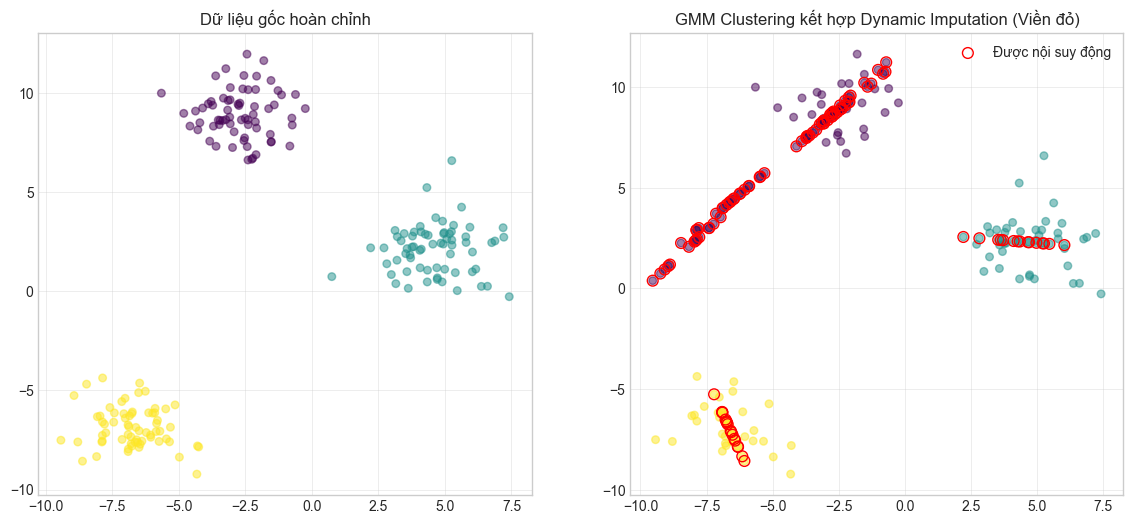

In [8]:
# Chạy luồng fit hoàn chỉnh từ module
gmm_full = GMMMissing(n_components=3, max_iter=200, random_state=42)
gmm_full.fit(X_incomplete)

print(f"Thuật toán hội tụ thành công sau {gmm_full.n_iter_} vòng lặp.")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_true[:, 0], X_true[:, 1], c=y_true, cmap='viridis', s=30, alpha=0.5)
plt.title("Dữ liệu gốc hoàn chỉnh")

plt.subplot(1, 2, 2)
y_pred = gmm_full.predict(gmm_full.X_final_)
plt.scatter(gmm_full.X_final_[:, 0], gmm_full.X_final_[:, 1], c=y_pred, cmap='viridis', s=30, alpha=0.5)

# Đánh dấu viền đỏ cho các tọa độ từng bị mất (nay đã nội suy)
missing_rows_idx = np.where(mask_missing.any(axis=1))[0]
plt.scatter(gmm_full.X_final_[missing_rows_idx, 0], gmm_full.X_final_[missing_rows_idx, 1], 
            facecolors='none', edgecolors='red', s=60, label='Được nội suy động')

plt.title("GMM Clustering kết hợp Dynamic Imputation (Viền đỏ)")
plt.legend()
plt.show()